In [1]:
import cellrank as cr
import scanpy as sc
import scvelo as scv
import seaborn as sns
import matplotlib.pyplot as plt
cr.settings.verbosity = 2
import warnings
import numpy as np
import pandas as pd
warnings.simplefilter("ignore", category=UserWarning)

import os
os.environ['OPENBLAS_NUM_THREADS'] = '4'   #set threads
os.environ['MKL_NUM_THREADS'] = '4'
os.environ['OMP_NUM_THREADS'] = '4'
os.environ['NUMEXPR_NUM_THREADS'] = '4'


sc.settings.verbosity = 0
sc.set_figure_params(
    dpi=80,
    dpi_save=600,
    facecolor="white",
    frameon=False,
    figsize=(4, 4)
)
# 设置全局 rcParams
plt.rcParams.update({
    'axes.spines.top': True,
    'axes.spines.right': True
})

In [2]:
###导入adata 其实跟08小节得到的数据一样
adata_a=sc.read_h5ad('./10_cytotrace2_拟时序分析/10_after_hb_Gr_subanndata.h5ad')

#### 读入假时间结果
pseudotime_res=pd.read_csv('./10_cytotrace2_拟时序分析/pseudotime_res_all.csv',index_col=0)

##合并假时间的数据到adata
pseudotime_col=[col for col in pseudotime_res.columns if "pseudotime" in col]
pseudotime_data=pseudotime_res[pseudotime_col]

adata_a.obs[pseudotime_col]=pseudotime_data

In [ ]:
#### Palantir_cellrank

In [3]:
## 计算cytotrace pseudotime
pk = cr.kernels.PseudotimeKernel(adata_a,time_key='Palantir_pseudotime')  ###改这个 time_key='Palantir_pseudotime'
# 计算转移概率矩阵
pk.compute_transition_matrix(threshold_scheme="hard")

100%|██████████| 33475/33475 [00:10<00:00, 3259.89cell/s]


PseudotimeKernel[n=33475, dnorm=False, scheme='hard', frac_to_keep=0.3]

saving figure to file ./figures/10_cellrank_palantir_plots.png


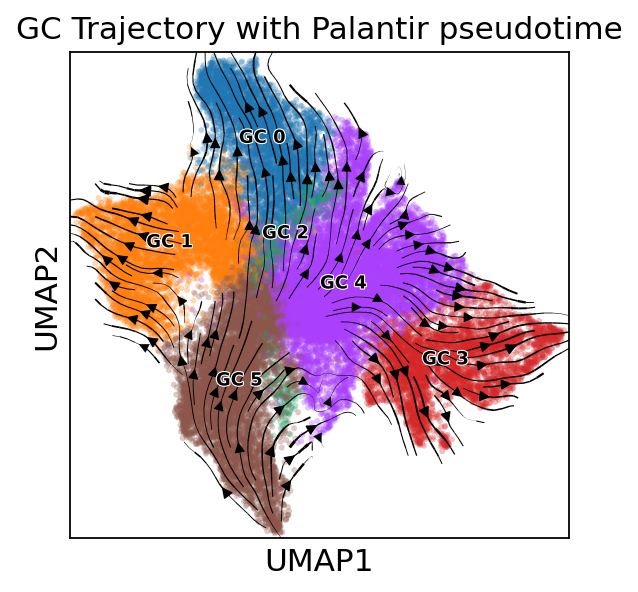

In [4]:
# 修改 Matplotlib 默认设置
plt.rcParams['axes.grid'] = False  # 关闭网格线
plt.rcParams['axes.facecolor'] = 'white'  # 设置背景为白色
# 调用 pk.plot_projection 方法进行绘图
pk.plot_projection(basis="X_umap", recompute=True, color="Gr_subannotation",
                   legend_fontsize='xx-small',
                   frameon=True,
                   title='GC Trajectory with Palantir pseudotime',
                   save='./figures/10_cellrank_palantir_plots.png'
                   )

#### DPT

In [5]:
## 计算cytotrace pseudotime
pk = cr.kernels.PseudotimeKernel(adata_a,time_key='dpt_pseudotime')  ###改这个 time_key='Palantir_pseudotime'
# 计算转移概率矩阵
pk.compute_transition_matrix(threshold_scheme="hard")


100%|██████████| 33475/33475 [00:10<00:00, 3062.79cell/s]


PseudotimeKernel[n=33475, dnorm=False, scheme='hard', frac_to_keep=0.3]

saving figure to file ./figures/10_cellrank_dpt_plots.png


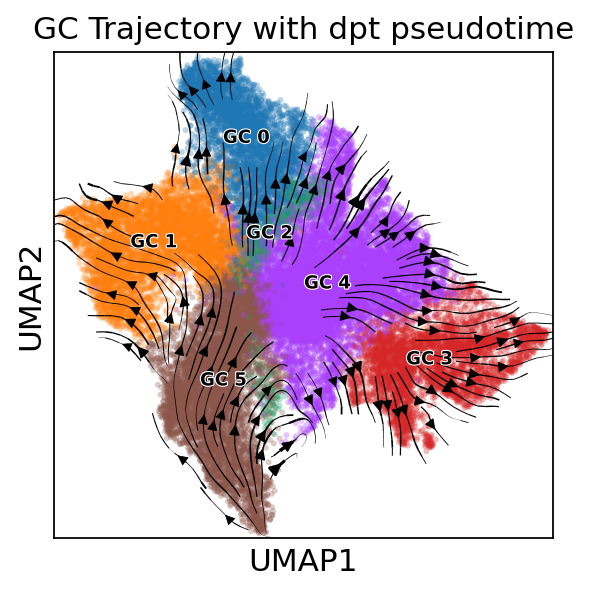

In [6]:
# 修改 Matplotlib 默认设置
plt.rcParams['axes.grid'] = False  # 关闭网格线
plt.rcParams['axes.facecolor'] = 'white'  # 设置背景为白色
# 调用 pk.plot_projection 方法进行绘图
pk.plot_projection(basis="X_umap", recompute=True, color="Gr_subannotation",
                   legend_fontsize='xx-small',
                   frameon=True,
                   title='GC Trajectory with dpt pseudotime',
                   save='./figures/10_cellrank_dpt_plots.png'
                   )

### monocle3

In [7]:
pk = cr.kernels.PseudotimeKernel(adata_a,time_key='monocle3_pseudotime')  ###改这个 time_key='Palantir_pseudotime'
# 计算转移概率矩阵
pk.compute_transition_matrix(threshold_scheme="hard")


100%|██████████| 33475/33475 [00:11<00:00, 2933.45cell/s]


PseudotimeKernel[n=33475, dnorm=False, scheme='hard', frac_to_keep=0.3]

saving figure to file ./figures/10_cellrank_monocle3_plots.png


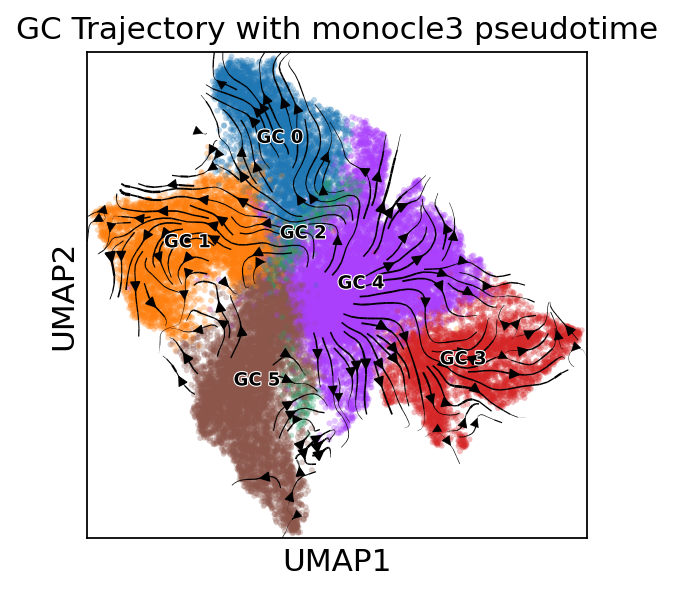

In [8]:
# 修改 Matplotlib 默认设置
plt.rcParams['axes.grid'] = False  # 关闭网格线
plt.rcParams['axes.facecolor'] = 'white'  # 设置背景为白色
# 调用 pk.plot_projection 方法进行绘图
pk.plot_projection(basis="X_umap", recompute=True, color="Gr_subannotation",
                   legend_fontsize='xx-small',
                   frameon=True,
                   title='GC Trajectory with monocle3 pseudotime',
                   save='./figures/10_cellrank_monocle3_plots.png'
                   )